# Escape sequence stats – analysis notebook

This notebook reads the CSV summaries in `summary_escape_stats.zip` and visualizes:

- **Example-level rate**: how many examples contain each escape type
- **Occurrence-level counts**: how often each escape type occurs
- Breakdowns by **dataset** and **format**

> Tip: run the first two cells and confirm the file list / columns.


In [1]:
# --- Imports ---
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point this to the *extracted* directory that contains many CSVs.
# Only files matching PATTERN will be loaded.
DIR_PATH = Path("out_hf_task_split")  # <-- change this
PATTERN = "summary_escape_stats_*.csv"

assert DIR_PATH.exists(), f"Not found: {DIR_PATH}"
print("DIR_PATH:", DIR_PATH.resolve())

DIR_PATH: /home/ubuntu/data_ubuntu/LLM2025/Advanced_Day8/out_hf_task_split


In [2]:
# --- Load all matching CSVs from the directory ---
def load_escape_stats_from_dir(dir_path: Path, pattern: str) -> pd.DataFrame:
    files = sorted(dir_path.glob(pattern))
    if not files:
        raise ValueError(f"No CSVs matched: {dir_path}/{pattern}")

    print("Matched CSV files:")
    for p in files:
        print(" -", p.name)

    rows = []
    for p in files:
        df = pd.read_csv(p)

        # Ensure expected columns exist (kept permissive for future files)
        expected = {
            "dataset", "format", "escape_type",
            "examples_total", "examples_usable",
            "examples_with_escape_total", "examples_with_escape_usable",
            "occurrences_total", "occurrences_usable",
        }
        missing = expected - set(df.columns)
        if missing:
            raise ValueError(f"{p.name}: missing columns: {sorted(missing)}")

        df = df.copy()
        df["source_file"] = p.name
        rows.append(df)

    out = pd.concat(rows, ignore_index=True)

    # Derived metrics
    out["example_rate_total"] = np.where(
        out["examples_total"] > 0,
        out["examples_with_escape_total"] / out["examples_total"],
        np.nan,
    )
    out["example_rate_usable"] = np.where(
        out["examples_usable"] > 0,
        out["examples_with_escape_usable"] / out["examples_usable"],
        np.nan,
    )
    out["occ_per_example_total"] = np.where(
        out["examples_total"] > 0,
        out["occurrences_total"] / out["examples_total"],
        np.nan,
    )
    out["occ_per_example_usable"] = np.where(
        out["examples_usable"] > 0,
        out["occurrences_usable"] / out["examples_usable"],
        np.nan,
    )
    return out

df = load_escape_stats_from_dir(DIR_PATH, PATTERN)

print("\nShape:", df.shape)
display(df.head(10))

Matched CSV files:
 - summary_escape_stats_daichira_structured-3k-mix-sft.csv
 - summary_escape_stats_daichira_structured-5k-mix-sft.csv
 - summary_escape_stats_daichira_structured-hard-sft-4k.csv
 - summary_escape_stats_u-10bei_structured_data_with_cot_dataset.csv
 - summary_escape_stats_u-10bei_structured_data_with_cot_dataset_512.csv
 - summary_escape_stats_u-10bei_structured_data_with_cot_dataset_512_v2.csv
 - summary_escape_stats_u-10bei_structured_data_with_cot_dataset_512_v4.csv
 - summary_escape_stats_u-10bei_structured_data_with_cot_dataset_512_v5.csv
 - summary_escape_stats_u-10bei_structured_data_with_cot_dataset_v2.csv

Shape: (339, 14)


,dataset,format,escape_type,examples_total,examples_usable,examples_with_escape_total,examples_with_escape_usable,occurrences_total,occurrences_usable,source_file,example_rate_total,example_rate_usable,occ_per_example_total,occ_per_example_usable
0,daichira/structured-3k-mix-sft,CSV,csv_quote_doubled,600,600,503,503,60000,60000,summary_escape_stats_daichira_structured-3k-mi...,0.838333,0.838333,100.000,100.000
1,daichira/structured-3k-mix-sft,CSV,csv_quoted_newline,600,600,450,450,1587,1587,summary_escape_stats_daichira_structured-3k-mi...,0.750000,0.750000,2.645,2.645
2,daichira/structured-3k-mix-sft,JSON,json_escape_b,600,600,0,0,0,0,summary_escape_stats_daichira_structured-3k-mi...,0.000000,0.000000,0.000,0.000
3,daichira/structured-3k-mix-sft,JSON,json_escape_f,600,600,0,0,0,0,summary_escape_stats_daichira_structured-3k-mi...,0.000000,0.000000,0.000,0.000
4,daichira/structured-3k-mix-sft,JSON,json_escape_n,600,600,0,0,0,0,summary_escape_stats_daichira_structured-3k-mi...,0.000000,0.000000,0.000,0.000
5,daichira/structured-3k-mix-sft,JSON,json_escape_r,600,600,0,0,0,0,summary_escape_stats_daichira_structured-3k-mi...,0.000000,0.000000,0.000,0.000
6,daichira/structured-3k-mix-sft,JSON,json_escape_t,600,600,0,0,0,0,summary_escape_stats_daichira_structured-3k-mi...,0.000000,0.000000,0.000,0.000
7,daichira/structured-3k-mix-sft,JSON,json_escape_u,600,600,0,0,0,0,summary_escape_stats_daichira_structured-3k-mi...,0.000000,0.000000,0.000,0.000
8,daichira/structured-3k-mix-sft,JSON,json_escaped_backslash,600,600,0,0,0,0,summary_escape_stats_daichira_structured-3k-mi...,0.000000,0.000000,0.000,0.000
9,daichira/structured-3k-mix-sft,JSON,json_escaped_quote,600,600,0,0,0,0,summary_escape_stats_daichira_structured-3k-mi...,0.000000,0.000000,0.000,0.000


In [3]:
# --- Quick sanity checks ---
print("Datasets:", sorted(df["dataset"].unique()))
print("Formats:", sorted(df["format"].unique()))
print("Escape types:", len(df["escape_type"].unique()))
display(df["escape_type"].value_counts().head(20))

Datasets: ['daichira/structured-3k-mix-sft', 'daichira/structured-5k-mix-sft', 'daichira/structured-hard-sft-4k', 'u-10bei/structured_data_with_cot_dataset', 'u-10bei/structured_data_with_cot_dataset_512', 'u-10bei/structured_data_with_cot_dataset_512_v2', 'u-10bei/structured_data_with_cot_dataset_512_v4', 'u-10bei/structured_data_with_cot_dataset_512_v5', 'u-10bei/structured_data_with_cot_dataset_v2']
Formats: ['CSV', 'JSON', 'TOML', 'XML', 'YAML']
Escape types: 39


escape_type
toml_escape_r             9
toml_escape_t             9
toml_escape_u             9
toml_escaped_backslash    9
toml_escape_U             9
toml_escape_f             9
toml_escape_b             9
yaml_escape_n             9
yaml_escape_r             9
yaml_escape_t             9
yaml_escape_u             9
yaml_escape_x             9
xml_num_hex               9
xml_quot                  9
toml_escape_n             9
xml_amp                   9
toml_escaped_quote        9
xml_apos                  9
xml_num_dec               9
xml_lt                    9
Name: count, dtype: int64

## 1) Example-level rates (per dataset)

Bar chart: `examples_with_escape_total / examples_total` for each escape type.


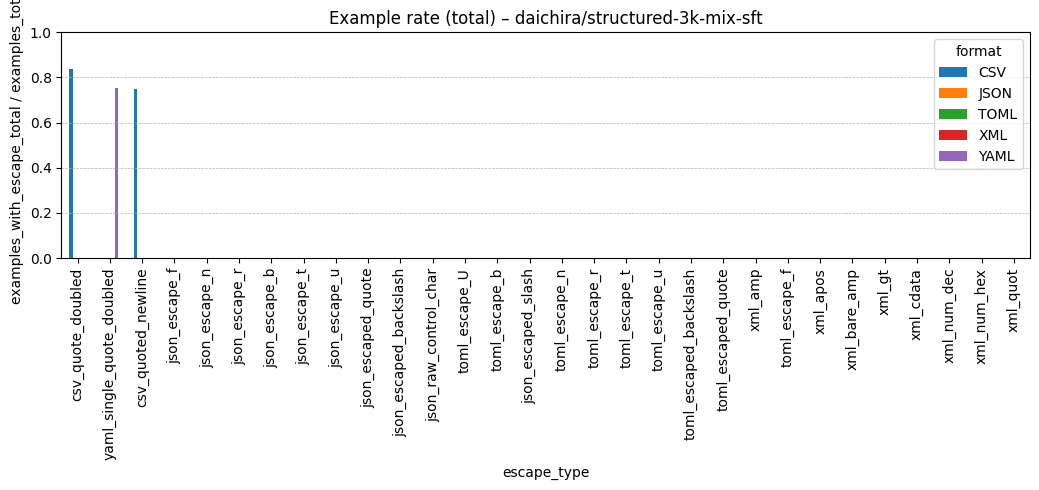

In [4]:
def plot_example_rates_for_dataset(df: pd.DataFrame, dataset: str, *, top_n: int | None = 25) -> None:
    sub = df[df["dataset"] == dataset].copy()
    if sub.empty:
        raise ValueError(f"dataset not found: {dataset}")

    # If multiple sources exist for same dataset/format/escape_type, sum counts.
    g = sub.groupby(["format", "escape_type"], as_index=False).agg(
        examples_total=("examples_total", "sum"),
        examples_with_escape_total=("examples_with_escape_total", "sum"),
    )
    g["example_rate_total"] = np.where(
        g["examples_total"] > 0,
        g["examples_with_escape_total"] / g["examples_total"],
        np.nan,
    )

    # Order by rate (overall)
    order = (
        g.groupby("escape_type")["example_rate_total"]
        .max()
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    if top_n is not None:
        order = order[:top_n]
        g = g[g["escape_type"].isin(order)]

    # Pivot to plot formats as grouped bars
    pv = g.pivot(index="escape_type", columns="format", values="example_rate_total").reindex(order)

    ax = pv.plot(kind="bar", figsize=(max(10, len(pv) * 0.35), 5))
    ax.set_title(f"Example rate (total) – {dataset}")
    ax.set_xlabel("escape_type")
    ax.set_ylabel("examples_with_escape_total / examples_total")
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Choose one dataset to start
plot_example_rates_for_dataset(df, sorted(df["dataset"].unique())[0], top_n=30)

## 2) Occurrence counts (per dataset)

Bar chart: total occurrences for each escape type (summed across formats).  
This helps spot escape types that are rare per-example but frequent when they appear.


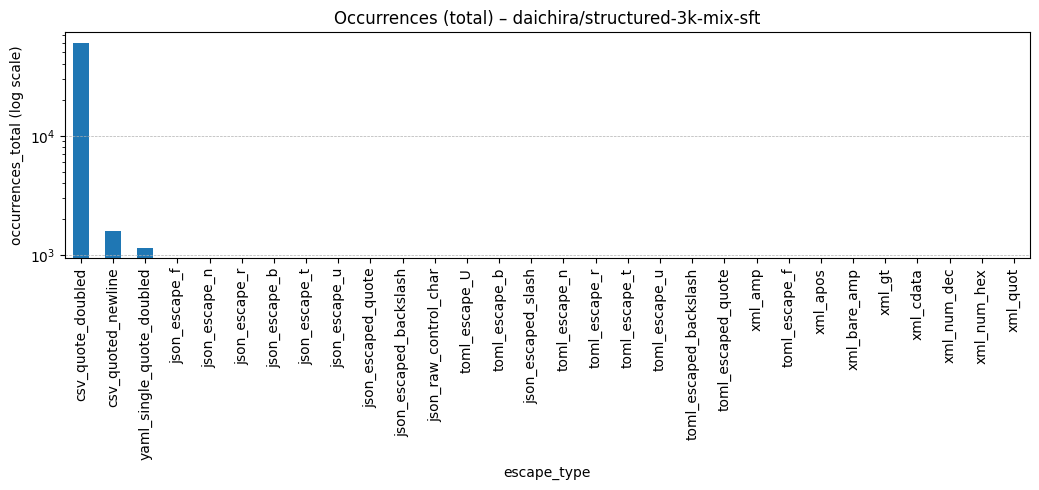

In [5]:
def plot_occurrences_for_dataset(df: pd.DataFrame, dataset: str, *, top_n: int = 30, use_log: bool = True) -> None:
    sub = df[df["dataset"] == dataset].copy()
    if sub.empty:
        raise ValueError(f"dataset not found: {dataset}")

    g = sub.groupby("escape_type", as_index=False).agg(
        occurrences_total=("occurrences_total", "sum"),
        examples_total=("examples_total", "sum"),
    )
    g["occ_per_example_total"] = np.where(g["examples_total"] > 0, g["occurrences_total"] / g["examples_total"], np.nan)
    g = g.sort_values("occurrences_total", ascending=False).head(top_n)

    ax = g.plot(kind="bar", x="escape_type", y="occurrences_total", figsize=(max(10, len(g) * 0.35), 5), legend=False)
    ax.set_title(f"Occurrences (total) – {dataset}")
    ax.set_xlabel("escape_type")
    ax.set_ylabel("occurrences_total")
    if use_log:
        ax.set_yscale("log")
        ax.set_ylabel("occurrences_total (log scale)")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

plot_occurrences_for_dataset(df, sorted(df["dataset"].unique())[0], top_n=30, use_log=True)

## 3) Compare datasets side-by-side (top escape types)

Heatmap-style table (not a plot): rows = escape types, columns = datasets, values = example rate.  
This is often the quickest way to compare changes between dataset variants.


In [6]:
# Aggregate across formats and sources
agg = df.groupby(["dataset", "escape_type"], as_index=False).agg(
    examples_total=("examples_total", "sum"),
    examples_with_escape_total=("examples_with_escape_total", "sum"),
    occurrences_total=("occurrences_total", "sum"),
)

agg["example_rate_total"] = np.where(
    agg["examples_total"] > 0,
    agg["examples_with_escape_total"] / agg["examples_total"],
    np.nan,
)

# Pick escape types that appear in at least one dataset (rate>0) and rank by max rate
rank = (
    agg.groupby("escape_type")["example_rate_total"]
    .max()
    .sort_values(ascending=False)
)
top_types = rank.head(25).index.tolist()

pv = (
    agg[agg["escape_type"].isin(top_types)]
    .pivot(index="escape_type", columns="dataset", values="example_rate_total")
    .reindex(top_types)
)

display(pv.style.format("{:.2%}").background_gradient(axis=None))

dataset,daichira/structured-3k-mix-sft,daichira/structured-5k-mix-sft,daichira/structured-hard-sft-4k,u-10bei/structured_data_with_cot_dataset,u-10bei/structured_data_with_cot_dataset_512,u-10bei/structured_data_with_cot_dataset_512_v2,u-10bei/structured_data_with_cot_dataset_512_v4,u-10bei/structured_data_with_cot_dataset_512_v5,u-10bei/structured_data_with_cot_dataset_v2
escape_type,,,,,,,,,
json_raw_control_char,0.00%,0.00%,nan%,100.00%,100.00%,100.00%,100.00%,94.38%,100.00%
csv_quoted_newline,75.00%,75.00%,nan%,89.00%,89.21%,87.02%,11.24%,8.86%,91.60%
csv_quote_doubled,83.83%,80.60%,nan%,85.20%,82.47%,81.17%,46.04%,53.83%,86.00%
yaml_single_quote_doubled,75.33%,77.00%,65.80%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
json_escape_n,0.00%,0.00%,nan%,12.60%,11.10%,13.12%,11.51%,8.92%,11.40%
toml_escape_n,0.00%,0.00%,0.00%,12.60%,10.80%,12.93%,12.13%,9.14%,11.40%
toml_escaped_quote,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,8.81%,0.00%
json_escape_t,0.00%,0.00%,nan%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
json_escape_r,0.00%,0.00%,nan%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


## 4) Export a combined CSV (optional)

Creates one merged CSV with the derived metrics, useful for other tools.


In [7]:
OUT_CSV = Path("escape_stats_merged.csv")
df.to_csv(OUT_CSV, index=False)
print("Wrote:", OUT_CSV.resolve())

Wrote: /home/ubuntu/data_ubuntu/LLM2025/Advanced_Day8/escape_stats_merged.csv


## 5) グラフを全データセット分まとめて作成（PNG保存）

このセクションは **データを見て自動的に**「見たい観点」を複数生成します。

- データセットごとに：
  1. **例ベース出現率（format別の棒グラフ）**：上位 escape_type
  2. **occurrence数（log棒グラフ）**：上位 escape_type
  3. **usable vs total の差**：出現率の散布図（フィルタで落ちているか）
  4. （formatが複数ある場合）**escape_type × format のヒートマップ**

- さらに全体として：
  - データセット別の **「最大の例ベース出現率」**（どれか1種でも多いものを見つける）
  - データセット別の **occurrences / example**（総量の目安）

> 注：escape_typeごとの `examples_with_escape_*` は、異なるescape_type間で同一例を共有し得るため、  
> 「データセット内でescapeが1つでもある例の割合（union）」は、この集計だけでは厳密には求まりません。  
> ここでは **escape_type別の詳細** と **総量の目安** を重視しています。


In [8]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = Path("figs_escape_stats")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _safe_name(s: str) -> str:
    s = str(s)
    s = re.sub(r"\s+", "_", s.strip())
    s = re.sub(r"[^0-9A-Za-z._-]+", "_", s)
    return s[:180] if len(s) > 180 else s

def savefig(fig, name: str, *, dpi: int = 200) -> Path:
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return out

print("FIG_DIR:", FIG_DIR.resolve())

FIG_DIR: /home/ubuntu/data_ubuntu/LLM2025/Advanced_Day8/figs_escape_stats


In [9]:
# --- Helper aggregations ---
def agg_by_dataset_format_escape(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby(["dataset", "format", "escape_type"], as_index=False).agg(
        examples_total=("examples_total", "sum"),
        examples_usable=("examples_usable", "sum"),
        examples_with_escape_total=("examples_with_escape_total", "sum"),
        examples_with_escape_usable=("examples_with_escape_usable", "sum"),
        occurrences_total=("occurrences_total", "sum"),
        occurrences_usable=("occurrences_usable", "sum"),
    )

g_dfe = agg_by_dataset_format_escape(df)
g_dfe["example_rate_total"] = np.where(
    g_dfe["examples_total"] > 0,
    g_dfe["examples_with_escape_total"] / g_dfe["examples_total"],
    np.nan,
)
g_dfe["example_rate_usable"] = np.where(
    g_dfe["examples_usable"] > 0,
    g_dfe["examples_with_escape_usable"] / g_dfe["examples_usable"],
    np.nan,
)

datasets = sorted(g_dfe["dataset"].unique())
formats = sorted(g_dfe["format"].unique())
print("datasets:", len(datasets))
print("formats:", formats)

datasets: 9
formats: ['CSV', 'JSON', 'TOML', 'XML', 'YAML']


In [10]:
# --- Plot generators ---
def plot_rates_grouped_bars(sub: pd.DataFrame, dataset: str, *, top_n: int = 30) -> Path:
    # Rank escape types by max rate across formats
    rank = (
        sub.groupby("escape_type")["example_rate_total"]
        .max()
        .sort_values(ascending=False)
    )
    top_types = rank.head(top_n).index.tolist()
    p = sub[sub["escape_type"].isin(top_types)].copy()

    pv = (
        p.pivot(index="escape_type", columns="format", values="example_rate_total")
        .reindex(top_types)
    )

    fig, ax = plt.subplots(figsize=(max(11, len(pv) * 0.38), 5.4))
    pv.plot(kind="bar", ax=ax)
    ax.set_title(f"[{dataset}] Example rate (total) by format – top {len(pv)} escape types")
    ax.set_xlabel("escape_type")
    ax.set_ylabel("examples_with_escape_total / examples_total")
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
    fig.tight_layout()

    return savefig(fig, f"{_safe_name(dataset)}__01_example_rate_total_by_format_top{len(pv)}")

def plot_occurrences_bar(sub: pd.DataFrame, dataset: str, *, top_n: int = 30, log: bool = True) -> Path:
    g = sub.groupby("escape_type", as_index=False).agg(
        occurrences_total=("occurrences_total", "sum"),
        examples_total=("examples_total", "sum"),
    )
    g["occ_per_example_total"] = np.where(g["examples_total"] > 0, g["occurrences_total"] / g["examples_total"], np.nan)
    g = g.sort_values("occurrences_total", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(max(11, len(g) * 0.38), 5.4))
    ax.bar(g["escape_type"], g["occurrences_total"])
    ax.set_title(f"[{dataset}] Occurrences (total) – top {len(g)} escape types")
    ax.set_xlabel("escape_type")
    ax.set_ylabel("occurrences_total" + (" (log scale)" if log else ""))
    if log:
        ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
    fig.tight_layout()

    return savefig(fig, f"{_safe_name(dataset)}__02_occurrences_total_top{len(g)}" + ("_log" if log else ""))

def plot_total_vs_usable_scatter(sub: pd.DataFrame, dataset: str, *, top_n: int = 80) -> Path:
    # Aggregate across formats to compare filtering impact
    a = sub.groupby("escape_type", as_index=False).agg(
        examples_total=("examples_total", "sum"),
        examples_usable=("examples_usable", "sum"),
        examples_with_escape_total=("examples_with_escape_total", "sum"),
        examples_with_escape_usable=("examples_with_escape_usable", "sum"),
    )
    a["rate_total"] = np.where(a["examples_total"] > 0, a["examples_with_escape_total"] / a["examples_total"], np.nan)
    a["rate_usable"] = np.where(a["examples_usable"] > 0, a["examples_with_escape_usable"] / a["examples_usable"], np.nan)

    # Focus on higher-impact types (by total rate)
    a = a.sort_values("rate_total", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    ax.scatter(a["rate_total"], a["rate_usable"])
    ax.plot([0, 1], [0, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"[{dataset}] Example rate: total vs usable (top {len(a)} by total rate)")
    ax.set_xlabel("rate_total")
    ax.set_ylabel("rate_usable")
    ax.grid(True, linestyle="--", linewidth=0.5)
    fig.tight_layout()

    return savefig(fig, f"{_safe_name(dataset)}__03_rate_total_vs_usable_scatter_top{len(a)}")

def plot_heatmap_escape_by_format(sub: pd.DataFrame, dataset: str, *, top_n: int = 40) -> Path | None:
    fmts = sorted(sub["format"].unique())
    if len(fmts) <= 1:
        return None

    # choose top escape types by max rate
    rank = (
        sub.groupby("escape_type")["example_rate_total"]
        .max()
        .sort_values(ascending=False)
    )
    top_types = rank.head(top_n).index.tolist()
    p = sub[sub["escape_type"].isin(top_types)].copy()

    pv = (
        p.pivot(index="escape_type", columns="format", values="example_rate_total")
        .reindex(top_types)
        .fillna(0.0)
    )

    fig_w = max(7.0, 0.6 * len(pv.columns) + 3.0)
    fig_h = max(6.0, 0.22 * len(pv.index) + 2.0)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(pv.values, aspect="auto")

    ax.set_title(f"[{dataset}] Heatmap: example rate (total) – top {len(pv)} escape types")
    ax.set_xlabel("format")
    ax.set_ylabel("escape_type")
    ax.set_xticks(np.arange(len(pv.columns)))
    ax.set_xticklabels(pv.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pv.index)))
    ax.set_yticklabels(pv.index)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("example_rate_total")

    fig.tight_layout()
    return savefig(fig, f"{_safe_name(dataset)}__04_heatmap_rate_total_escape_by_format_top{len(pv)}")

In [11]:
# --- Run: generate per-dataset figures ---
generated = []

for dataset in datasets:
    sub = g_dfe[g_dfe["dataset"] == dataset].copy()
    if sub.empty:
        continue

    # Decide top_n based on variety: keep charts readable.
    n_types = sub["escape_type"].nunique()
    top_n_rates = 30 if n_types > 40 else min(30, n_types)
    top_n_occ = 30 if n_types > 40 else min(30, n_types)
    top_n_scatter = 80 if n_types > 100 else min(80, n_types)

    p1 = plot_rates_grouped_bars(sub, dataset, top_n=top_n_rates)
    p2 = plot_occurrences_bar(sub, dataset, top_n=top_n_occ, log=True)
    p3 = plot_total_vs_usable_scatter(sub, dataset, top_n=top_n_scatter)
    p4 = plot_heatmap_escape_by_format(sub, dataset, top_n=min(40, n_types))

    generated += [p1, p2, p3]
    if p4 is not None:
        generated.append(p4)

print(f"Generated {len(generated)} PNGs under {FIG_DIR}/")
# show a few paths
for p in generated[:10]:
    print(" -", p)

Generated 36 PNGs under figs_escape_stats/
 - figs_escape_stats/daichira_structured-3k-mix-sft__01_example_rate_total_by_format_top30.png
 - figs_escape_stats/daichira_structured-3k-mix-sft__02_occurrences_total_top30_log.png
 - figs_escape_stats/daichira_structured-3k-mix-sft__03_rate_total_vs_usable_scatter_top39.png
 - figs_escape_stats/daichira_structured-3k-mix-sft__04_heatmap_rate_total_escape_by_format_top39.png
 - figs_escape_stats/daichira_structured-5k-mix-sft__01_example_rate_total_by_format_top30.png
 - figs_escape_stats/daichira_structured-5k-mix-sft__02_occurrences_total_top30_log.png
 - figs_escape_stats/daichira_structured-5k-mix-sft__03_rate_total_vs_usable_scatter_top39.png
 - figs_escape_stats/daichira_structured-5k-mix-sft__04_heatmap_rate_total_escape_by_format_top39.png
 - figs_escape_stats/daichira_structured-hard-sft-4k__01_example_rate_total_by_format_top27.png
 - figs_escape_stats/daichira_structured-hard-sft-4k__02_occurrences_total_top27_log.png


In [12]:
# --- Overall dataset-level summary figures ---
# Metric 1: "max example rate" among escape types (per dataset), aggregated across formats.
agg_ds_et = g_dfe.groupby(["dataset", "escape_type"], as_index=False).agg(
    examples_total=("examples_total", "sum"),
    examples_with_escape_total=("examples_with_escape_total", "sum"),
    occurrences_total=("occurrences_total", "sum"),
)
agg_ds_et["rate_total"] = np.where(
    agg_ds_et["examples_total"] > 0,
    agg_ds_et["examples_with_escape_total"] / agg_ds_et["examples_total"],
    np.nan,
)
# for each dataset, find escape_type with maximum rate_total
best = agg_ds_et.sort_values(["dataset", "rate_total"], ascending=[True, False]).groupby("dataset", as_index=False).head(1)
best = best.sort_values("rate_total", ascending=False)

fig, ax = plt.subplots(figsize=(max(10, len(best) * 0.35), 5.2))
ax.bar(best["dataset"], best["rate_total"])
ax.set_title("Per dataset: max example rate (total) among escape types")
ax.set_xlabel("dataset")
ax.set_ylabel("max example_rate_total")
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
fig.tight_layout()
p_best = savefig(fig, "ALL__01_dataset_max_example_rate_total")

# Metric 2: occurrences per example (sum over escape types) – note: a "total volume" proxy
agg_ds = g_dfe.groupby("dataset", as_index=False).agg(
    examples_total=("examples_total", "sum"),
    occurrences_total=("occurrences_total", "sum"),
)
agg_ds["occ_per_example_total_sum"] = np.where(
    agg_ds["examples_total"] > 0,
    agg_ds["occurrences_total"] / agg_ds["examples_total"],
    np.nan,
)
agg_ds = agg_ds.sort_values("occ_per_example_total_sum", ascending=False)

fig, ax = plt.subplots(figsize=(max(10, len(agg_ds) * 0.35), 5.2))
ax.bar(agg_ds["dataset"], agg_ds["occ_per_example_total_sum"])
ax.set_title("Per dataset: occurrences per example (sum over escape types) – volume proxy")
ax.set_xlabel("dataset")
ax.set_ylabel("occurrences_total / examples_total")
ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
fig.tight_layout()
p_occ = savefig(fig, "ALL__02_dataset_occ_per_example_total_sum")

print("Wrote:")
print(" -", p_best)
print(" -", p_occ)

display(best[["dataset","escape_type","rate_total","occurrences_total","examples_total"]].rename(columns={"rate_total":"max_rate_total"}))

Wrote:
 - figs_escape_stats/ALL__01_dataset_max_example_rate_total.png
 - figs_escape_stats/ALL__02_dataset_occ_per_example_total_sum.png


,dataset,escape_type,max_rate_total,occurrences_total,examples_total
155,u-10bei/structured_data_with_cot_dataset_512,json_raw_control_char,1.000000,24242,1000
311,u-10bei/structured_data_with_cot_dataset_v2,json_raw_control_char,1.000000,12471,500
116,u-10bei/structured_data_with_cot_dataset,json_raw_control_char,1.000000,11069,500
233,u-10bei/structured_data_with_cot_dataset_512_v4,json_raw_control_char,1.000000,14336,912
194,u-10bei/structured_data_with_cot_dataset_512_v2,json_raw_control_char,1.000000,25620,1075
272,u-10bei/structured_data_with_cot_dataset_512_v5,json_raw_control_char,0.943833,15786,908
0,daichira/structured-3k-mix-sft,csv_quote_doubled,0.838333,60000,600
39,daichira/structured-5k-mix-sft,csv_quote_doubled,0.806000,49028,500
104,daichira/structured-hard-sft-4k,yaml_single_quote_doubled,0.658000,3048,2000


In [13]:
# --- Convenience: list generated PNG files ---
pngs = sorted(FIG_DIR.glob("*.png"))
print("PNG count:", len(pngs))
display(pd.DataFrame({"png": [p.name for p in pngs]}).head(50))

PNG count: 38


,png
0,ALL__01_dataset_max_example_rate_total.png
1,ALL__02_dataset_occ_per_example_total_sum.png
2,daichira_structured-3k-mix-sft__01_example_rat...
3,daichira_structured-3k-mix-sft__02_occurrences...
4,daichira_structured-3k-mix-sft__03_rate_total_...
5,daichira_structured-3k-mix-sft__04_heatmap_rat...
6,daichira_structured-5k-mix-sft__01_example_rat...
7,daichira_structured-5k-mix-sft__02_occurrences...
8,daichira_structured-5k-mix-sft__03_rate_total_...
9,daichira_structured-5k-mix-sft__04_heatmap_rat...
